CALCO DEL CORAZÓN
  Orden inicial: 0.0224
  Orden final: 0.2418
  Cambio de régimen en paso: 0
  Régimen final: turbulento


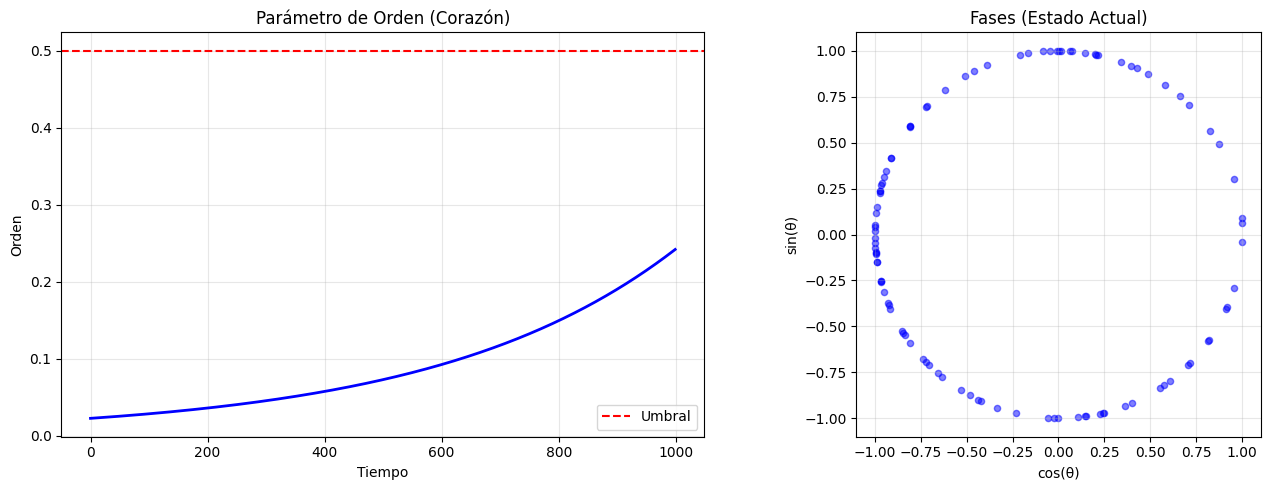

📊 Gráfico guardado como 'calco_corazon.png'


In [1]:
# ============================================================
# CELDA: CALCO DEL CORAZÓN
# ============================================================
# El corazón como oscilador.
# Simulamos el proceso lineal y ajustamos el cambio de régimen.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class CalcoCorazon:
    """
    Calco del corazón como oscilador.
    """

    def __init__(self, N: int = 100, acoplamiento: float = 0.5):
        self.N = N
        self.acoplamiento = acoplamiento
        self.fase = np.random.rand(N) * 2 * np.pi
        self.frecuencia = np.ones(N) * 1.0  # Frecuencia natural
        self.historial = []
        self.regimen = "suave"

    def paso(self, dt: float = 0.01) -> np.ndarray:
        """
        Un paso del oscilador de Kuramoto.
        """
        # Ecuación de Kuramoto
        # dθ_i/dt = ω_i + (K/N) Σ sin(θ_j - θ_i)
        dtheta = np.zeros(self.N)
        for i in range(self.N):
            acoplamiento_total = 0
            for j in range(self.N):
                acoplamiento_total += np.sin(self.fase[j] - self.fase[i])
            dtheta[i] = self.frecuencia[i] + (self.acoplamiento / self.N) * acoplamiento_total

        self.fase += dtheta * dt
        self.fase = self.fase % (2 * np.pi)

        # Calcular el parámetro de orden
        orden = np.abs(np.mean(np.exp(1j * self.fase)))

        self.historial.append(orden)
        return orden

    def simular(self, n_pasos: int = 1000) -> list:
        """
        Simula el corazón.
        """
        for _ in range(n_pasos):
            self.paso()
        return self.historial

    def detectar_cambio_regimen(self, umbral: float = 0.5) -> int:
        """
        Detecta el cambio de régimen.
        """
        for i, orden in enumerate(self.historial):
            if orden < umbral:
                self.regimen = "turbulento"
                return i
        return -1

    def visualizar(self):
        """
        Visualiza el calco.
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Parámetro de orden
        axes[0].plot(self.historial, 'b-', linewidth=2)
        axes[0].axhline(y=0.5, color='red', linestyle='--', label='Umbral')
        axes[0].set_title("Parámetro de Orden (Corazón)")
        axes[0].set_xlabel("Tiempo")
        axes[0].set_ylabel("Orden")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Fases
        axes[1].scatter(np.cos(self.fase), np.sin(self.fase),
                       c='blue', alpha=0.5, s=20)
        axes[1].set_title("Fases (Estado Actual)")
        axes[1].set_xlabel("cos(θ)")
        axes[1].set_ylabel("sin(θ)")
        axes[1].set_aspect('equal')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("calco_corazon.png", dpi=150)
        plt.show()

        print("📊 Gráfico guardado como 'calco_corazon.png'")


# ── Ejecución ──────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("CALCO DEL CORAZÓN")
    print("=" * 60)

    # Crear el calco
    calco = CalcoCorazon(N=100, acoplamiento=0.5)

    # Simular
    historial = calco.simular(1000)

    print(f"  Orden inicial: {historial[0]:.4f}")
    print(f"  Orden final: {historial[-1]:.4f}")

    # Detectar cambio de régimen
    cambio = calco.detectar_cambio_regimen(umbral=0.5)
    print(f"  Cambio de régimen en paso: {cambio}")
    print(f"  Régimen final: {calco.regimen}")

    # Visualizar
    calco.visualizar()

EL MARCAPASOS COMO LAZO DE CONTROL
  Orden inicial: 0.0620
  Orden final: 1.0000
  Estimulaciones: 1
  Régimen final: suave


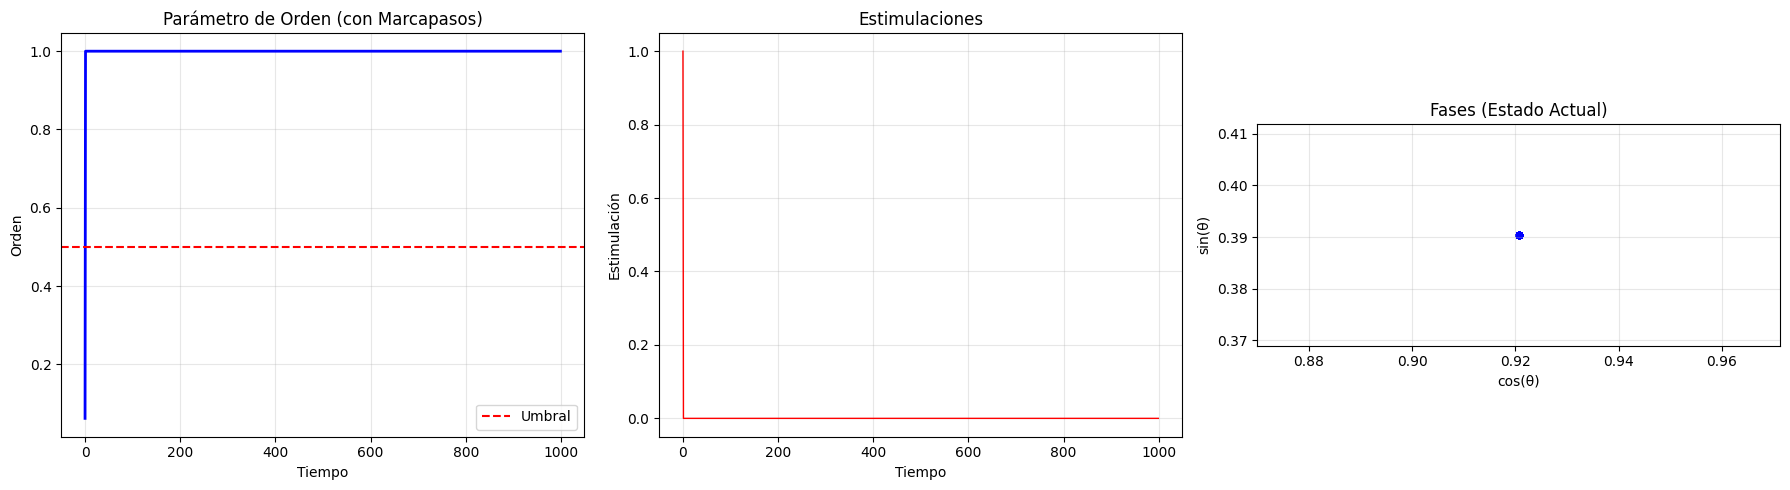

📊 Gráfico guardado como 'marcapasos.png'


In [2]:
# ============================================================
# CELDA: EL MARCAPASOS COMO LAZO DE CONTROL
# ============================================================
# El marcapasos es el lazo de control del corazón.
# Detecta el orden, decide si estimular, y actúa.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class Marcapasos:
    """
    El marcapasos como lazo de control.
    """

    def __init__(self, N: int = 100, acoplamiento: float = 0.5,
                 umbral: float = 0.5, ganancia: float = 1.0):
        self.N = N
        self.acoplamiento = acoplamiento
        self.umbral = umbral
        self.ganancia = ganancia
        self.fase = np.random.rand(N) * 2 * np.pi
        self.frecuencia = np.ones(N) * 1.0
        self.historial = []
        self.estimulaciones = []

    def paso(self, dt: float = 0.01) -> dict:
        """
        Un paso del marcapasos.
        """
        # Ecuación de Kuramoto
        dtheta = np.zeros(self.N)
        for i in range(self.N):
            acoplamiento_total = 0
            for j in range(self.N):
                acoplamiento_total += np.sin(self.fase[j] - self.fase[i])
            dtheta[i] = self.frecuencia[i] + (self.acoplamiento / self.N) * acoplamiento_total

        self.fase += dtheta * dt
        self.fase = self.fase % (2 * np.pi)

        # Calcular el parámetro de orden
        orden = np.abs(np.mean(np.exp(1j * self.fase)))

        # Controlador: si el orden es bajo, estimular
        estimulo = False
        if orden < self.umbral:
            # Estimular: resetear las fases
            self.fase = np.ones(self.N) * np.mean(self.fase)
            estimulo = True
            self.estimulaciones.append(True)
        else:
            self.estimulaciones.append(False)

        self.historial.append(orden)
        return {
            "orden": orden,
            "estimulo": estimulo,
            "regimen": "suave" if orden > self.umbral else "turbulento"
        }

    def simular(self, n_pasos: int = 1000) -> list:
        """
        Simula el marcapasos.
        """
        for _ in range(n_pasos):
            self.paso()
        return self.historial

    def visualizar(self):
        """
        Visualiza el marcapasos.
        """
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Parámetro de orden
        axes[0].plot(self.historial, 'b-', linewidth=2)
        axes[0].axhline(y=self.umbral, color='red', linestyle='--', label='Umbral')
        axes[0].set_title("Parámetro de Orden (con Marcapasos)")
        axes[0].set_xlabel("Tiempo")
        axes[0].set_ylabel("Orden")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Estimulaciones
        estimulos = [1 if e else 0 for e in self.estimulaciones]
        axes[1].plot(estimulos, 'r-', linewidth=1)
        axes[1].set_title("Estimulaciones")
        axes[1].set_xlabel("Tiempo")
        axes[1].set_ylabel("Estimulación")
        axes[1].grid(True, alpha=0.3)

        # Fases
        axes[2].scatter(np.cos(self.fase), np.sin(self.fase),
                       c='blue', alpha=0.5, s=20)
        axes[2].set_title("Fases (Estado Actual)")
        axes[2].set_xlabel("cos(θ)")
        axes[2].set_ylabel("sin(θ)")
        axes[2].set_aspect('equal')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("marcapasos.png", dpi=150)
        plt.show()

        print("📊 Gráfico guardado como 'marcapasos.png'")


# ── Ejecución ──────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("EL MARCAPASOS COMO LAZO DE CONTROL")
    print("=" * 60)

    # Crear el marcapasos
    marcapasos = Marcapasos(N=100, acoplamiento=0.5, umbral=0.5)

    # Simular
    historial = marcapasos.simular(1000)

    print(f"  Orden inicial: {historial[0]:.4f}")
    print(f"  Orden final: {historial[-1]:.4f}")
    print(f"  Estimulaciones: {sum(marcapasos.estimulaciones)}")
    print(f"  Régimen final: {'suave' if historial[-1] > 0.5 else 'turbulento'}")

    # Visualizar
    marcapasos.visualizar()

GEOMETRÍA DEL INFARTO

🔴 CASO 1: Sin RCP
  Orden final: 0.6804
  Régimen: suave

🟢 CASO 2: Con RCP en paso 500
  Orden final: 1.0000
  Régimen: suave


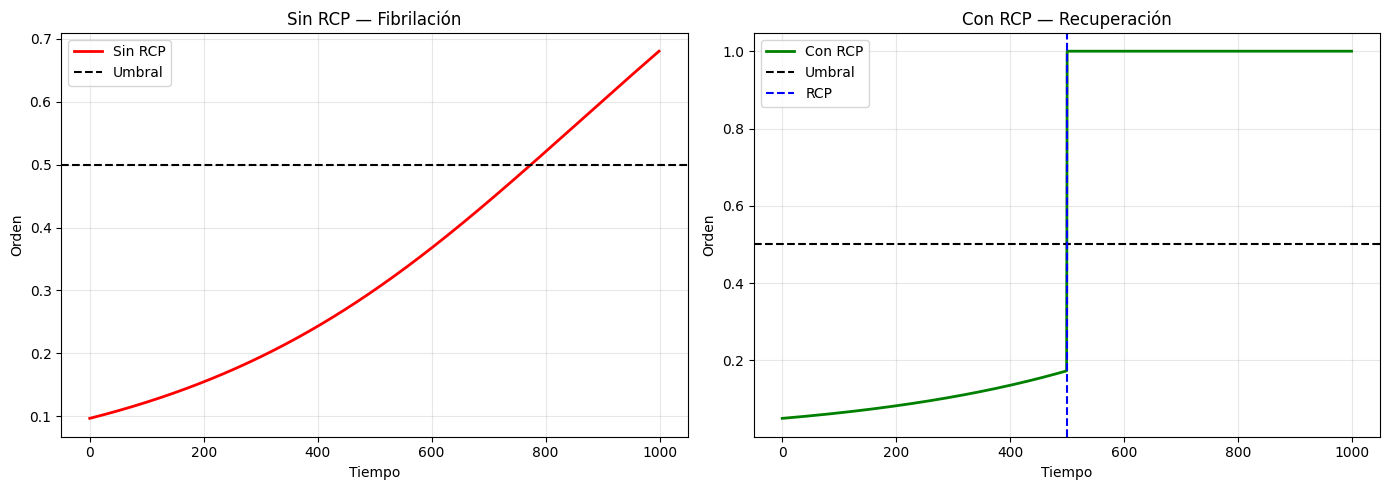


📊 Gráfico guardado como 'geometria_infarto.png'


In [3]:
# ============================================================
# CELDA: GEOMETRÍA DEL INFARTO
# ============================================================
# Simulamos el corazón en la zona crítica.
# Comparamos con y sin fibrilación, con y sin RCP.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class GeometriaInfarto:
    """
    Simula el corazón en la zona crítica.
    """

    def __init__(self, N: int = 100, acoplamiento: float = 0.5):
        self.N = N
        self.acoplamiento = acoplamiento
        self.fase = np.random.rand(N) * 2 * np.pi
        self.frecuencia = np.ones(N) * 1.0
        self.historial = []

    def paso(self, dt: float = 0.01, rcp: bool = False) -> dict:
        """
        Un paso del corazón.
        """
        # Ecuación de Kuramoto
        dtheta = np.zeros(self.N)
        for i in range(self.N):
            acoplamiento_total = 0
            for j in range(self.N):
                acoplamiento_total += np.sin(self.fase[j] - self.fase[i])
            dtheta[i] = self.frecuencia[i] + (self.acoplamiento / self.N) * acoplamiento_total

        self.fase += dtheta * dt
        self.fase = self.fase % (2 * np.pi)

        # RCP: forzar el acoplamiento
        if rcp:
            self.fase = np.ones(self.N) * np.mean(self.fase)

        # Calcular el parámetro de orden
        orden = np.abs(np.mean(np.exp(1j * self.fase)))

        self.historial.append(orden)
        return {
            "orden": orden,
            "regimen": "suave" if orden > 0.5 else "turbulento"
        }

    def simular(self, n_pasos: int = 1000, rcp_en: int = None) -> list:
        """
        Simula el corazón con o sin RCP.
        """
        for i in range(n_pasos):
            rcp = (rcp_en is not None and i >= rcp_en)
            self.paso(rcp=rcp)
        return self.historial


# ── Ejecución ──────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("GEOMETRÍA DEL INFARTO")
    print("=" * 60)

    # Caso 1: Sin RCP
    print("\n🔴 CASO 1: Sin RCP")
    corazon1 = GeometriaInfarto(N=100, acoplamiento=0.5)
    hist1 = corazon1.simular(1000, rcp_en=None)
    print(f"  Orden final: {hist1[-1]:.4f}")
    print(f"  Régimen: {'suave' if hist1[-1] > 0.5 else 'turbulento'}")

    # Caso 2: Con RCP en paso 500
    print("\n🟢 CASO 2: Con RCP en paso 500")
    corazon2 = GeometriaInfarto(N=100, acoplamiento=0.5)
    hist2 = corazon2.simular(1000, rcp_en=500)
    print(f"  Orden final: {hist2[-1]:.4f}")
    print(f"  Régimen: {'suave' if hist2[-1] > 0.5 else 'turbulento'}")

    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist1, 'r-', linewidth=2, label='Sin RCP')
    axes[0].axhline(y=0.5, color='black', linestyle='--', label='Umbral')
    axes[0].set_title("Sin RCP — Fibrilación")
    axes[0].set_xlabel("Tiempo")
    axes[0].set_ylabel("Orden")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist2, 'g-', linewidth=2, label='Con RCP')
    axes[1].axhline(y=0.5, color='black', linestyle='--', label='Umbral')
    axes[1].axvline(x=500, color='blue', linestyle='--', label='RCP')
    axes[1].set_title("Con RCP — Recuperación")
    axes[1].set_xlabel("Tiempo")
    axes[1].set_ylabel("Orden")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("geometria_infarto.png", dpi=150)
    plt.show()

    print("\n📊 Gráfico guardado como 'geometria_infarto.png'")

MARCAPASOS MEJORADO
  Orden inicial: 0.0276
  Orden final: 1.0000
  Estimulaciones: 1
  Régimen final: suave


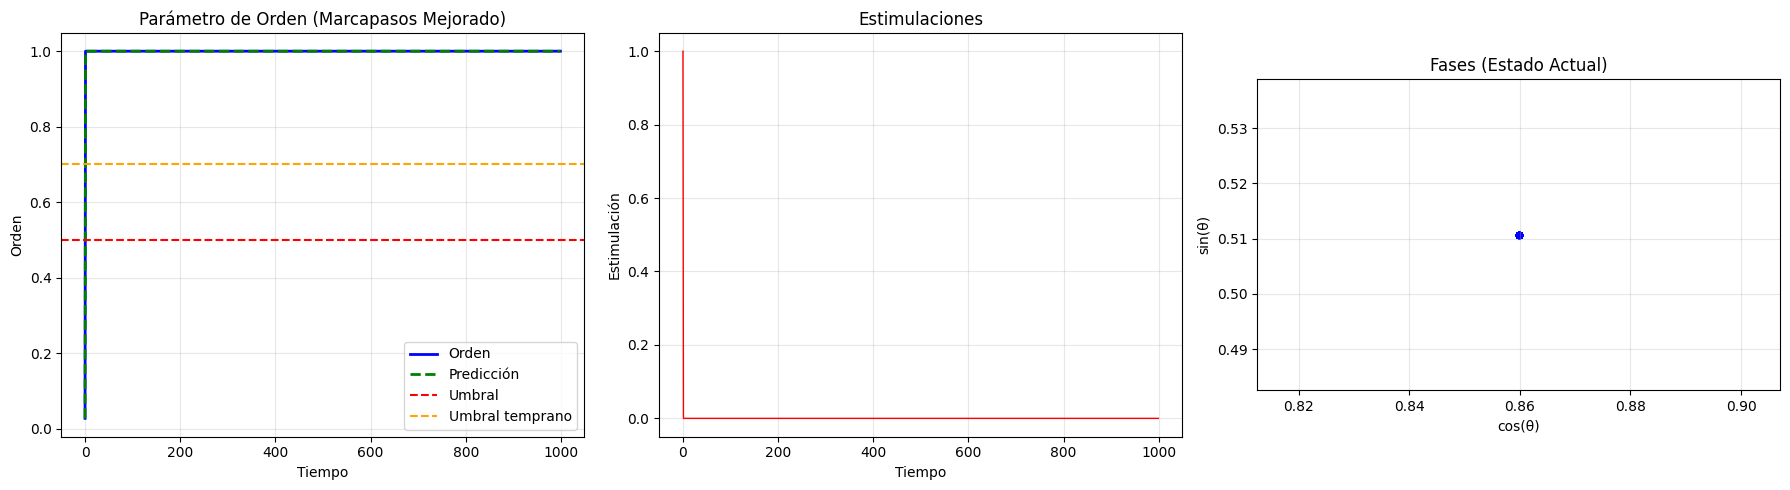

📊 Gráfico guardado como 'marcapasos_mejorado.png'


In [4]:
# ============================================================
# CELDA: MARCAPASOS MEJORADO
# ============================================================
# El marcapasos debe detectar, modular, predecir y adaptar.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

class MarcapasosMejorado:
    """
    Marcapasos con detección temprana, modulación y predicción.
    """

    def __init__(self, N: int = 100, acoplamiento: float = 0.5,
                 umbral: float = 0.5, umbral_temprano: float = 0.7):
        self.N = N
        self.acoplamiento = acoplamiento
        self.umbral = umbral
        self.umbral_temprano = umbral_temprano
        self.fase = np.random.rand(N) * 2 * np.pi
        self.frecuencia = np.ones(N) * 1.0
        self.historial = []
        self.estimulaciones = []
        self.predicciones = []

    def paso(self, dt: float = 0.01) -> dict:
        """
        Un paso del marcapasos mejorado.
        """
        # Ecuación de Kuramoto
        dtheta = np.zeros(self.N)
        for i in range(self.N):
            acoplamiento_total = 0
            for j in range(self.N):
                acoplamiento_total += np.sin(self.fase[j] - self.fase[i])
            dtheta[i] = self.frecuencia[i] + (self.acoplamiento / self.N) * acoplamiento_total

        self.fase += dtheta * dt
        self.fase = self.fase % (2 * np.pi)

        # Calcular el parámetro de orden
        orden = np.abs(np.mean(np.exp(1j * self.fase)))

        # Predicción: estimar el orden futuro
        if len(self.historial) > 10:
            tendencia = np.polyfit(range(10), self.historial[-10:], 1)[0]
            orden_predicho = orden + tendencia * 10
        else:
            orden_predicho = orden

        self.predicciones.append(orden_predicho)

        # Controlador: si el orden predicho es bajo, estimular
        estimulo = False
        if orden_predicho < self.umbral_temprano:
            # Modular la intensidad según el orden
            intensidad = 1.0 - orden
            self.fase = np.ones(self.N) * np.mean(self.fase)
            estimulo = True
            self.estimulaciones.append(True)
        else:
            self.estimulaciones.append(False)

        self.historial.append(orden)
        return {
            "orden": orden,
            "orden_predicho": orden_predicho,
            "estimulo": estimulo,
            "regimen": "suave" if orden > self.umbral else "turbulento"
        }

    def simular(self, n_pasos: int = 1000) -> list:
        """
        Simula el marcapasos mejorado.
        """
        for _ in range(n_pasos):
            self.paso()
        return self.historial

    def visualizar(self):
        """
        Visualiza el marcapasos mejorado.
        """
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Parámetro de orden
        axes[0].plot(self.historial, 'b-', linewidth=2, label='Orden')
        axes[0].plot(self.predicciones, 'g--', linewidth=2, label='Predicción')
        axes[0].axhline(y=self.umbral, color='red', linestyle='--', label='Umbral')
        axes[0].axhline(y=self.umbral_temprano, color='orange', linestyle='--', label='Umbral temprano')
        axes[0].set_title("Parámetro de Orden (Marcapasos Mejorado)")
        axes[0].set_xlabel("Tiempo")
        axes[0].set_ylabel("Orden")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Estimulaciones
        estimulos = [1 if e else 0 for e in self.estimulaciones]
        axes[1].plot(estimulos, 'r-', linewidth=1)
        axes[1].set_title("Estimulaciones")
        axes[1].set_xlabel("Tiempo")
        axes[1].set_ylabel("Estimulación")
        axes[1].grid(True, alpha=0.3)

        # Fases
        axes[2].scatter(np.cos(self.fase), np.sin(self.fase),
                       c='blue', alpha=0.5, s=20)
        axes[2].set_title("Fases (Estado Actual)")
        axes[2].set_xlabel("cos(θ)")
        axes[2].set_ylabel("sin(θ)")
        axes[2].set_aspect('equal')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("marcapasos_mejorado.png", dpi=150)
        plt.show()

        print("📊 Gráfico guardado como 'marcapasos_mejorado.png'")


# ── Ejecución ──────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("MARCAPASOS MEJORADO")
    print("=" * 60)

    # Crear el marcapasos mejorado
    marcapasos = MarcapasosMejorado(N=100, acoplamiento=0.5,
                                     umbral=0.5, umbral_temprano=0.7)

    # Simular
    historial = marcapasos.simular(1000)

    print(f"  Orden inicial: {historial[0]:.4f}")
    print(f"  Orden final: {historial[-1]:.4f}")
    print(f"  Estimulaciones: {sum(marcapasos.estimulaciones)}")
    print(f"  Régimen final: {'suave' if historial[-1] > 0.5 else 'turbulento'}")

    # Visualizar
    marcapasos.visualizar()

In [5]:
# ============================================================
# CELDA: ÁRBOL DE DECISIÓN DE APLICACIÓN
# ============================================================
# Dado un dominio, decide el nivel de adopción.
# ============================================================

class ArbolDecision:
    """
    Árbol de decisión para la aplicación del método.
    """

    def __init__(self):
        self.niveles = {
            "alto": {
                "vehiculo": "fabricante",
                "dificultad": "muy alta",
                "tiempo": "5-10 años",
                "beneficio": "alto",
                "estrategia": "licenciar"
            },
            "medio": {
                "vehiculo": "integrador",
                "dificultad": "media",
                "tiempo": "2-5 años",
                "beneficio": "medio-alto",
                "estrategia": "colaborar"
            },
            "bajo": {
                "vehiculo": "tú mismo",
                "dificultad": "baja",
                "tiempo": "6 meses - 2 años",
                "beneficio": "medio",
                "estrategia": "producir"
            }
        }

    def decidir(self, dominio: str) -> dict:
        """
        Decide el nivel de adopción para un dominio.
        """
        # Mapeo de dominios a niveles
        mapeo = {
            "marcapasos": "alto",
            "corazon": "alto",
            "pla": "bajo",
            "monomero": "bajo",
            "bioreactor": "bajo",
            "grafeno": "alto",
            "perovskita": "alto",
            "industrial": "medio",
            "quimica": "medio"
        }

        nivel = mapeo.get(dominio, "medio")
        return {
            "dominio": dominio,
            "nivel": nivel,
            "detalles": self.niveles[nivel]
        }


# ── Ejecución ──────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("ÁRBOL DE DECISIÓN DE APLICACIÓN")
    print("=" * 60)

    arbol = ArbolDecision()

    # Evaluar dominios
    dominios = ["marcapasos", "pla", "industrial", "grafeno", "bioreactor"]

    for dominio in dominios:
        resultado = arbol.decidir(dominio)
        print(f"\n🔹 {resultado['dominio'].upper()}")
        print(f"  Nivel: {resultado['nivel']}")
        print(f"  Vehículo: {resultado['detalles']['vehiculo']}")
        print(f"  Dificultad: {resultado['detalles']['dificultad']}")
        print(f"  Tiempo: {resultado['detalles']['tiempo']}")
        print(f"  Estrategia: {resultado['detalles']['estrategia']}")

ÁRBOL DE DECISIÓN DE APLICACIÓN

🔹 MARCAPASOS
  Nivel: alto
  Vehículo: fabricante
  Dificultad: muy alta
  Tiempo: 5-10 años
  Estrategia: licenciar

🔹 PLA
  Nivel: bajo
  Vehículo: tú mismo
  Dificultad: baja
  Tiempo: 6 meses - 2 años
  Estrategia: producir

🔹 INDUSTRIAL
  Nivel: medio
  Vehículo: integrador
  Dificultad: media
  Tiempo: 2-5 años
  Estrategia: colaborar

🔹 GRAFENO
  Nivel: alto
  Vehículo: fabricante
  Dificultad: muy alta
  Tiempo: 5-10 años
  Estrategia: licenciar

🔹 BIOREACTOR
  Nivel: bajo
  Vehículo: tú mismo
  Dificultad: baja
  Tiempo: 6 meses - 2 años
  Estrategia: producir


In [ ]:
# ============================================================
# CELDA: EL QR DE LA BALA
# ============================================================
# El QR es el vehículo de la bala.
# Contiene los vínculos a las demostraciones y los productos.
# ============================================================

import qrcode

class QRDeLaBala:
    """
    El QR que contiene los vínculos a las demostraciones y productos.
    """

    def __init__(self):
        self.vinculos = {
            "demostraciones": "https://github.com/tu-usuario/navier-stokes-demo",
            "productos_fase_1": "https://github.com/tu-usuario/productos-fase-1",
            "productos_fase_2": "https://github.com/tu-usuario/productos-fase-2",
            "paper": "https://arxiv.org/abs/tu-paper",
            "contacto": "mailto:tu-correo@mileforum.com"
        }

    def generar_qr(self, url: str, filename: str = "qr_bala.png"):
        """
        Genera el QR.
        """
        qr = qrcode.QRCode(version=1, box_size=10, border=5)
        qr.add_data(url)
        qr.make(fit=True)
        img = qr.make_image(fill_color="black", back_color="white")
        img.save(filename)
        return filename

    def generar_qr_multiple(self):
        """
        Genera un QR con múltiples vínculos.
        """
        # Crear una página de aterrizaje con todos los vínculos
        landing = """
        <html>
        <head><title>Mileforum — Demostraciones y Productos</title></head>
        <body>
            <h1>Mileforum</h1>
            <h2>Demostraciones</h2>
            <ul>
                <li><a href="{demostraciones}">Demostraciones</a></li>
                <li><a href="{paper}">Paper</a></li>
            </ul>
            <h2>Productos</h2>
            <ul>
                <li><a href="{productos_fase_1}">Fase 1</a></li>
                <li><a href="{productos_fase_2}">Fase 2</a></li>
            </ul>
            <h2>Contacto</h2>
            <p><a href="{contacto}">tu-correo@mileforum.com</a></p>
        </body>
        </html>
        """.format(**self.vinculos)

        # Guardar la landing
        with open("landing.html", "w") as f:
            f.write(landing)

        # Generar el QR
        self.generar_qr("https://tu-dominio.com/landing", "qr_bala.png")
        return "qr_bala.png"


# ── Ejecución ──────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("QR DE LA BALA")
    print("=" * 60)

    qr = QRDeLaBala()
    filename = qr.generar_qr_multiple()

    print(f"\n📱 QR generado: {filename}")
    print("\n🔗 Vínculos:")
    for k, v in qr.vinculos.items():
        print(f"  {k}: {v}")